In [41]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [42]:
#load dataset

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

In [43]:
#cleaning data
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Age_missing"] = df["Age"].isna().astype(int)
df["Age"] = df.groupby(["Pclass","Sex"])["Age"].transform(lambda s: s.fillna(s.median()))
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")


In [44]:
#Q.1 survival rate by class and gender

survival = df.groupby(["Pclass","Sex"]).agg(
    survived_rate=("Survived","mean"),
    count=("Survived","size"),
    fare_mean=("Fare","mean")
).reset_index()
survival.sort_values("survived_rate", ascending=False).head()


C:\Users\Batab\AppData\Local\Temp\ipykernel_31248\738987254.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival = df.groupby(["Pclass","Sex"]).agg(


,Pclass,Sex,survived_rate,count,fare_mean
0,1,female,0.968085,94,106.125798
2,2,female,0.921053,76,21.970121
4,3,female,0.500000,144,16.118810
1,1,male,0.368852,122,67.226127
3,2,male,0.157407,108,19.741782


In [45]:
#Q.2 is the age missing related with the survival rate?

df.groupby("Age_missing")["Survived"].mean()

Age_missing
0    0.406162
1    0.293785
Name: Survived, dtype: float64

In [46]:
#Q.3 Which ports (Embarked) have different rates?

df.groupby("Embarked")["Survived"].agg(["mean","size"]).sort_values("mean", ascending=False)


C:\Users\Batab\AppData\Local\Temp\ipykernel_31248\435368368.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Embarked")["Survived"].agg(["mean","size"]).sort_values("mean", ascending=False)


,mean,size
Embarked,,
C,0.553571,168
Q,0.389610,77
S,0.339009,646


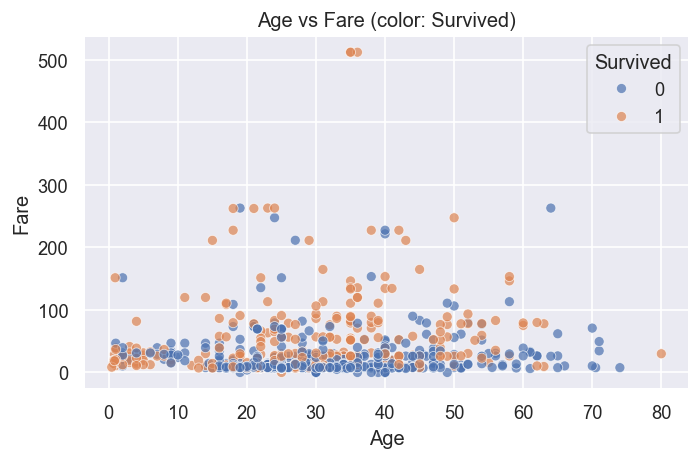

In [47]:
#Scatterplot: Age vs Fare 
plt.figure(figsize=(6,4), dpi=120)
sns.scatterplot(data=df,x="Age", y="Fare", hue="Survived", alpha=0.7)
plt.title("Age vs Fare (color: Survived)")
plt.tight_layout()
plt.show()

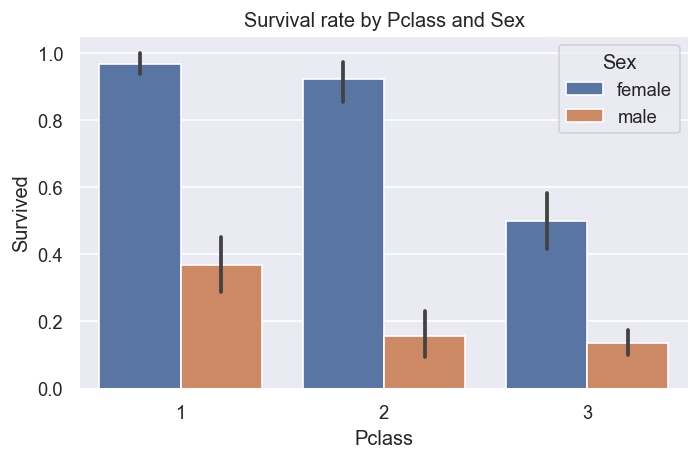

In [48]:
#Barplot: survival rate mean by class and sex

plt.figure(figsize=(6,4), dpi=120)
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex",  estimator=np.mean, errorbar="ci")
plt.title("Survival rate by Pclass and Sex")
plt.tight_layout()
plt.show()


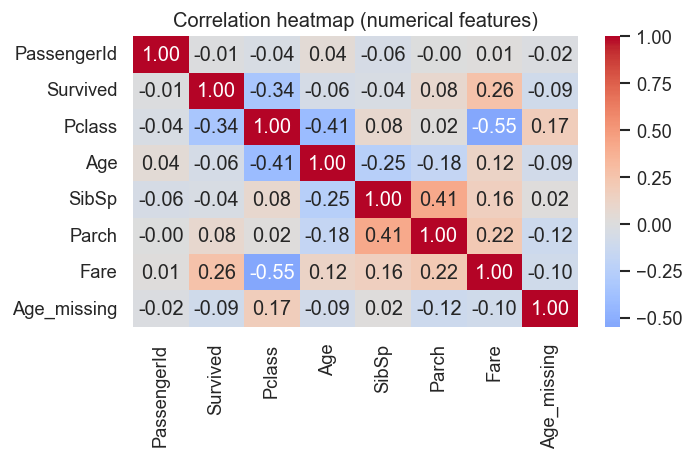

In [49]:
#Heatmap: numerical correlations
plt.figure(figsize=(6,4), dpi=120)
corr = df.select_dtypes(include="number").corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numerical features)")
plt.tight_layout(); plt.show()

In [51]:
res = (
  df
  .assign(Age_missing=lambda d: d["Age"].isna().astype(int))
  .pipe(lambda d: d.assign(Age=d.groupby(["Pclass","Sex"])["Age"]
                              .transform(lambda s: s.fillna(s.median()))))
)


C:\Users\Batab\AppData\Local\Temp\ipykernel_31248\4275230365.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .pipe(lambda d: d.assign(Age=d.groupby(["Pclass","Sex"])["Age"]


In [60]:
#E1. Calcola: sopravvivenza media per Embarked e Sex, ordina per tasso.

ans1 = (df.groupby(["Embarked", "Sex"], observed=True)["Survived"]
        .mean()
        .reset_index()
        .sort_values("Survived",ascending=False)
)

ans1

,Embarked,Sex,Survived
0,C,female,0.876712
2,Q,female,0.750000
4,S,female,0.692683
1,C,male,0.305263
5,S,male,0.174603
3,Q,male,0.073171


<Axes: xlabel='FamilySize', ylabel='Survived'>

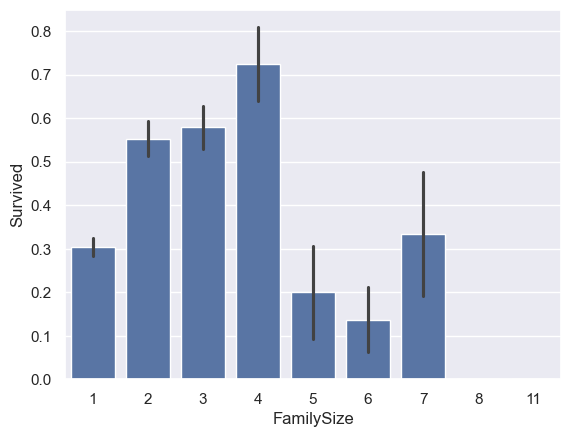

In [71]:
#E2. Crea FamilySize = SibSp + Parch + 1 e verifica relazione con sopravvivenza (barplot).
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

sns.barplot(data=df, x="FamilySize", y="Survived", estimator=np.mean, errorbar="se")